# Python in Search Algorithm

Dapat menggunakan library networkx.

**NetworkX** is a Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.

https://networkx.github.io/




## Library and Visualization

Visualisasi algoritma BFS dan DFS https://visualgo.net/en/dfsbfs

Untuk membuat visualisasi graph kita membutuhkan library matplotlib.
https://networkx.github.io/documentation/stable/_modules/networkx/drawing/nx_pylab.html



(0, 2, {})
(0, 4, {})
(0, 6, {})
(0, 8, {})
(1, 3, {})
(1, 9, {})
(3, 5, {})
(5, 7, {})
(7, 9, {})


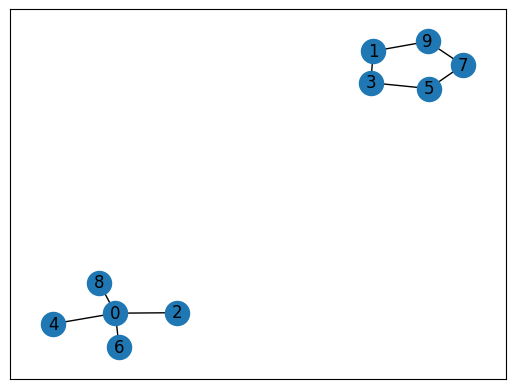

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

g = nx.Graph()

# add nodes
for i in range(0, 10):
  g.add_node(i)

# add edges
g.add_edge(1, 3)
g.add_edge(3, 5)
g.add_edge(5, 7)
g.add_edge(7, 9)
g.add_edge(9, 1)

g.add_edge(0, 2)
g.add_edge(0, 4)
g.add_edge(0, 6)
g.add_edge(0, 8)

for edge in g.edges(data=True):
      print(edge)
# draw a graph
nx.draw_networkx(g, with_labels=True)


plt.show()

### BFS Visualization
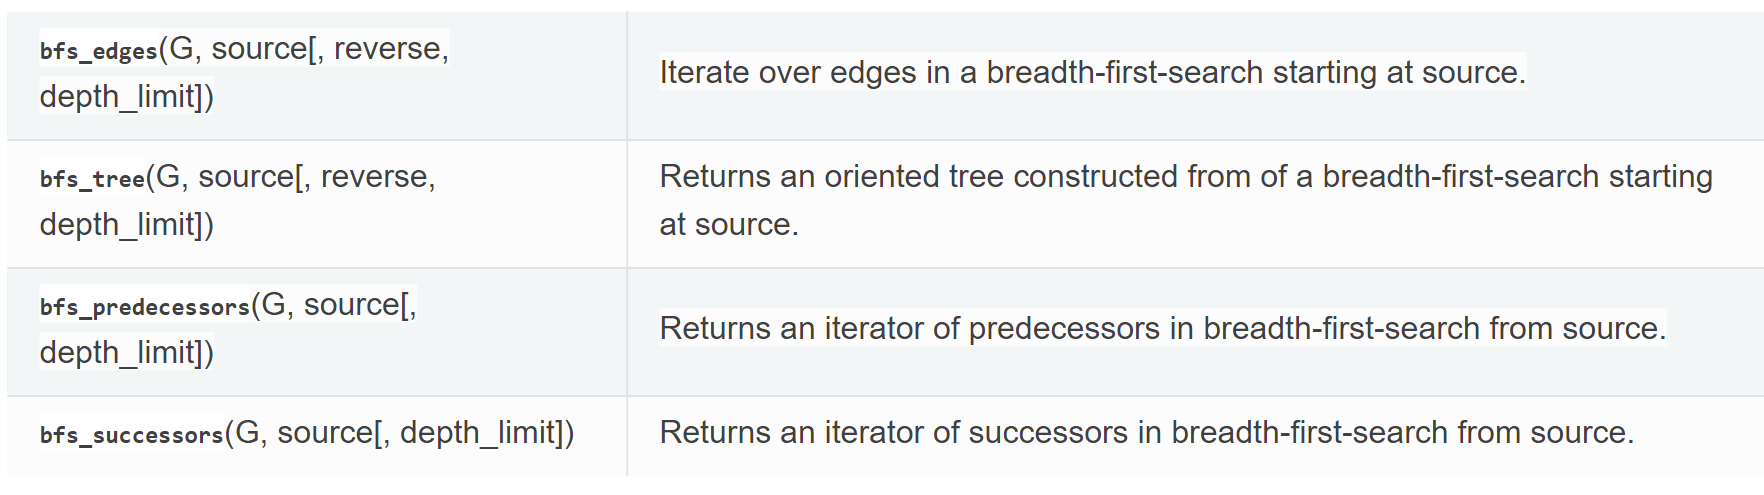

https://networkx.github.io/documentation/stable/_modules/networkx/algorithms/traversal/breadth_first_search.html



### DFS Visualization

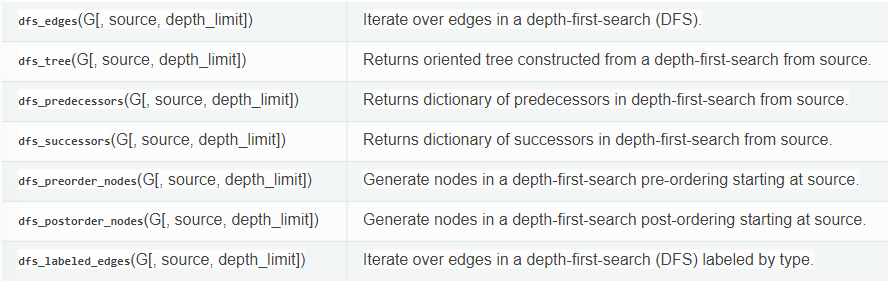

https://networkx.org/documentation/stable/_modules/networkx/algorithms/traversal/depth_first_search.html

## BFS (Breadth First Search)


Breadth First Search (BFS) adalah algoritma penelusuran grafik yang mengunjungi semua simpul grafik secara menyeluruh. Dimulai dari simpul akar dan mengunjungi semua tetangga pada kedalaman saat ini sebelum beralih ke level berikutnya.

### Cara Kerja
Cara kerja algoritma Breadth First Search yaitu masukkan simpul ujung ke dalam sebuah antrean kemudian ambil simpul dari awal antrean. Lakukan pengecekan apakah simpul awal merupakan solusi. Jika simpul merupakan solusi pencarian selesai dan hasil dikembalikan. Jika simpul bukan merupakan solusi, masukan seluruh simpul yang bertetangga dengan simpul tersebut. Apabila semua simpul sudah dicek dan antrean kosong, pencarian selesai dengan mengembalikan hasil solusi tidak ditemukan. Pencarian diulang dari simpul awal antrean.



**Kelebihan BFS**

Tidak akan menemui jalan buntu.
Jika ada satu solusi, maka BFS akan menemukannya. Dan jika ada lebih dari satu solusi, maka solusi minimum akan ditemukan.

**Kekurangan BFS**

Membutuhkan memori yang cukup banyak, karena menyimpan semua node dalam satu pohon.
Membutuhkan waktu yang cukup lama, karena akan menguji n level untuk mendapatkan solusi pada level ke-(n+1).

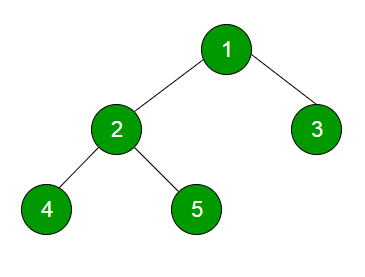

### Implementasi BFS

In [9]:
# Contoh dengan OOP
# Recursive Python program for level
# order traversal of Binary Tree

class Node:
    def __init__(self, key):
        self.data = key
        self.left = None
        self.right = None


# Function to  print level order traversal of tree
def printLevelOrder(root):
    h = height(root)
    for i in range(1, h+1):
        printCurrentLevel(root, i)


# Print nodes at a current level
def printCurrentLevel(root, level):
    if root is None:
        return
    if level == 1:
        print(root.data, end=" ")
    elif level > 1:
        printCurrentLevel(root.left, level-1)
        printCurrentLevel(root.right, level-1)


# Compute the height of a tree-
def height(node):
    if node is None:
        return 0
    else:
        lheight = height(node.left)
        rheight = height(node.right)
        if lheight > rheight:
            return lheight+1
        else:
            return rheight+1


if __name__ == '__main__':
    root = Node(1)
    root.left = Node(2)
    root.right = Node(3)
    root.left.left = Node(4)
    root.left.right = Node(5)
    printLevelOrder(root)

1 2 3 4 5 

In [10]:
# Python program to print level
# order traversal using Queue

class Node:
    def __init__(self, key):
        self.data = key
        self.left = None
        self.right = None

# Iterative Method to print the
# height of a binary tree
def printLevelOrder(root):

    # Base Case
    if root is None:
        return

    # Create an empty queue
    # for level order traversal
    queue = []

    # Enqueue Root and initialize height
    queue.append(root)

    while(len(queue) > 0):

        # Print front of queue and
        # remove it from queue
        print(queue[0].data, end=" ")
        node = queue.pop(0)

        # Enqueue left child
        if node.left is not None:
            queue.append(node.left)

        # Enqueue right child
        if node.right is not None:
            queue.append(node.right)


# Driver Program to test above function
if __name__ == '__main__':
    root = Node(1)
    root.left = Node(2)
    root.right = Node(3)
    root.left.left = Node(4)
    root.left.right = Node(5)
    printLevelOrder(root)

1 2 3 4 5 

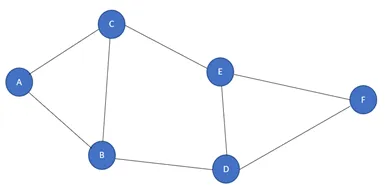

In [11]:
from collections import deque

#Tanpa OOP
def bfs(graph, node):
    visited = []
    queue = deque([node])

    while queue:
        current_node = queue.popleft()
        if current_node not in visited:
            print(current_node, end=' ')
            visited.append(current_node)
            queue.extend(graph[current_node] - set(visited))

graph = {

    'A': set(['B', 'C']),
    'B': set(['A', 'D', 'E']),
    'C': set(['A', 'F']),
    'D': set(['B']),
    'E': set(['B', 'F']),
    'F': set(['C', 'E'])
}

bfs(graph, 'A')


A B C E D F 

## DFS (Depth First Search)

DFS (Depth-First Search) adalah algoritma pencarian yang digunakan untuk menjelajahi atau menelusuri struktur data seperti graf atau pohon. Prinsip dasar dari DFS adalah menjelajahi cabang atau node yang lebih dalam terlebih dahulu sebelum kembali dan memeriksa node lain di tingkat yang sama.

### Cara Kerja
1. Mulai dari node awal (root).
2. Jelajahi node tetangga pertama yang belum dikunjungi.
3. Ulangi langkah 2 hingga mencapai node paling dalam.
4. Setelah tidak ada lagi node yang dapat dijelajahi, kembali (backtrack) ke node sebelumnya dan eksplorasi node tetangga lainnya.
5. Proses berlanjut hingga semua node telah dikunjungi.

**Kelebihan DFS**

Membutuhkan memori yang relatif kecil, karena hanya node-node pada lintasan yang aktif saja yang disimpan.

**Kekurangan DFS**

Tidak menjamin menemukan solusi optimal karena dapat terjebak pada jalur/lintasan yang panjang sebelum menemukan solusi. DFS juga rentan terhadap infinite loop pada graf dengan siklus jika tidak ada mekanisme untuk melacak node yang sudah dikunjungi.



Contoh Graf (V = 5, E = 5)

- vertex = 0, 1, 2, 3, 4
- edges = {{1, 2}, {1, 0}, {0, 2}, {2, 3}, {2, 4}}

Input Source = 1


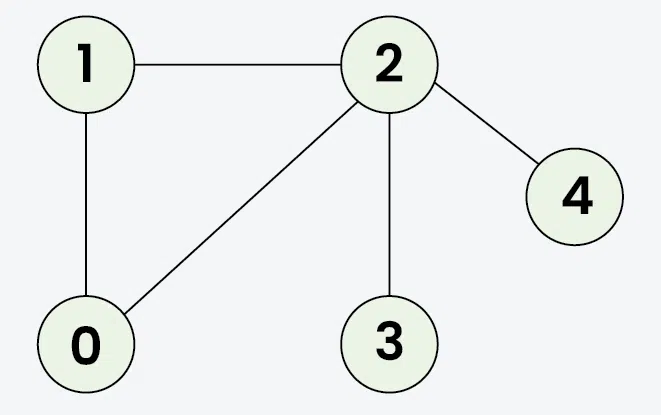

Proses
- Start at 1: Mark as visited. Output: 1
- Move to 2: Mark as visited. Output: 2
- Move to 0: Mark as visited. Output: 0 (backtrack to 2)
- Move to 3: Mark as visited. Output: 3 (backtrack to 2)
- Move to 4: Mark as visited. Output: 4 (backtrack to 1)


Output = 1 2 0 3 4

### Implementasi DFS


In [13]:
# DFS INPUT SOURCE ON UNDIRECTED GRAPH
def add_edge(adj, s, t):
    # Add edge from vertex s to t
    adj[s].append(t)
    # Due to undirected Graph
    adj[t].append(s)


def dfs_rec(adj, visited, s):
    # Mark the current vertex as visited
    visited[s] = True

    # Print the current vertex
    print(s, end=" ")

    # Recursively visit all adjacent vertices
    # that are not visited yet
    for i in adj[s]:
        if not visited[i]:
            dfs_rec(adj, visited, i)


def dfs(adj, s):
    visited = [False] * len(adj)
    # Call the recursive DFS function
    dfs_rec(adj, visited, s)


if __name__ == "__main__":
    V = 5

    # Create an adjacency list for the graph
    adj = [[] for _ in range(V)]

    # Define the edges of the graph
    edges = [[1, 2], [1, 0], [2, 0], [2, 3], [2, 4]]

    # Populate the adjacency list with edges
    for e in edges:
        add_edge(adj, e[0], e[1])

    # Input source from the user
    source = int(input("Input source vertex (0-4): "))

    print("DFS from source:", source)
    dfs(adj, source)

Input source vertex (0-4): 0
DFS from source: 0
0 1 2 3 4 

In [14]:
# DFS COMPLETE TRAVERSAL (INCLUDE DISCONECTED GRAPH)
class Graph:
    def __init__(self, vertices):
        # Adjacency list
        self.adj = [[] for _ in range(vertices)]

    def add_edge(self, s, t):
        self.adj[s].append(t)
        self.adj[t].append(s)

    def dfs_rec(self, visited, s):
        visited[s] = True
        print(s, end=" ")

        # Recursively visit all adjacent vertices
        # that are not visited yet
        for i in self.adj[s]:
            if not visited[i]:
                self.dfs_rec(visited, i)

    def dfs(self):
        visited = [False] * len(self.adj)

        # Loop through all vertices to handle disconnected
        # graph
        for i in range(len(self.adj)):
            if not visited[i]:
                  # Perform DFS from unvisited vertex
                self.dfs_rec(visited, i)


if __name__ == "__main__":
    V = 6  # Number of vertices
    graph = Graph(V)

    # Define the edges of the graph
    edges = [(1, 2), (2, 0), (0, 3), (4, 5)]

    # Populate the adjacency list with edges
    for edge in edges:
        graph.add_edge(edge[0], edge[1])

    print("Complete DFS:")
    graph.dfs()  # Perform DFS

Complete DFS:
0 2 1 3 4 5 

## A* Algoritm
Algoritma A* adalah teknik populer dan efisien untuk pencarian jalur terpendek dan penelusuran graf. Digunakan untuk mendekati jalur terpendek dalam situasi nyata seperti peta dan permainan yang memiliki banyak hambatan.

### Cara Kerja
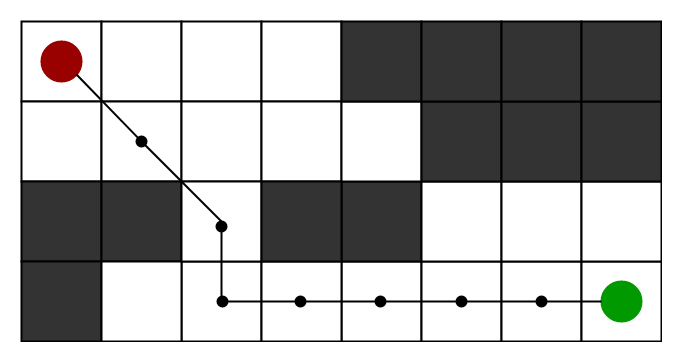

Mulai dari sel sumber `merah` menuju sel tujuan `hijau` di grid yang memiliki berbagai hambatan.

**Parameter Utama:**
1. `g`: Biaya perpindahan dari titik awal ke sel tertentu mengikuti jalur yang dihasilkan.
2. `h`: Estimasi biaya perpindahan dari sel tersebut ke tujuan (heuristik).
3. `f = g + h`: Total biaya yang digunakan untuk memilih node berikutnya.

Proses:
1. Inisialisasi daftar terbuka `Open List` dan daftar tertutup `Closed List`.
2. Pilih node dengan nilai f terendah dari Open List.
3. Proses node tersebut dan tambahkan ke Closed List.
4. Evaluasi semua penerus (successors) dan perbarui nilai g, h, dan f.
5. Ulangi hingga tujuan ditemukan atau Open List kosong.

### Implementasi A*

In [15]:
import math
import heapq

# Define the Cell class
class Cell:
    def __init__(self):
        self.parent_i = 0  # Parent cell's row index
        self.parent_j = 0  # Parent cell's column index
        self.f = float('inf')  # Total cost of the cell (g + h)
        self.g = float('inf')  # Cost from start to this cell
        self.h = 0  # Heuristic cost from this cell to destination

# Define the size of the grid
ROW = 9
COL = 10

# Check if a cell is valid (within the grid)
def is_valid(row, col):
    return (row >= 0) and (row < ROW) and (col >= 0) and (col < COL)

# Check if a cell is unblocked
def is_unblocked(grid, row, col):
    return grid[row][col] == 1

# Check if a cell is the destination
def is_destination(row, col, dest):
    return row == dest[0] and col == dest[1]

# Calculate the heuristic value of a cell (Euclidean distance to destination)
def calculate_h_value(row, col, dest):
    return ((row - dest[0]) ** 2 + (col - dest[1]) ** 2) ** 0.5

# Trace the path from source to destination
def trace_path(cell_details, dest):
    print("The Path is ")
    path = []
    row = dest[0]
    col = dest[1]

    # Trace the path from destination to source using parent cells
    while not (cell_details[row][col].parent_i == row and cell_details[row][col].parent_j == col):
        path.append((row, col))
        temp_row = cell_details[row][col].parent_i
        temp_col = cell_details[row][col].parent_j
        row = temp_row
        col = temp_col

    # Add the source cell to the path
    path.append((row, col))
    # Reverse the path to get the path from source to destination
    path.reverse()

    # Print the path
    for i in path:
        print("->", i, end=" ")
    print()

# Implement the A* search algorithm
def a_star_search(grid, src, dest):
    # Check if the source and destination are valid
    if not is_valid(src[0], src[1]) or not is_valid(dest[0], dest[1]):
        print("Source or destination is invalid")
        return

    # Check if the source and destination are unblocked
    if not is_unblocked(grid, src[0], src[1]) or not is_unblocked(grid, dest[0], dest[1]):
        print("Source or the destination is blocked")
        return

    # Check if we are already at the destination
    if is_destination(src[0], src[1], dest):
        print("We are already at the destination")
        return

    # Initialize the closed list (visited cells)
    closed_list = [[False for _ in range(COL)] for _ in range(ROW)]
    # Initialize the details of each cell
    cell_details = [[Cell() for _ in range(COL)] for _ in range(ROW)]

    # Initialize the start cell details
    i = src[0]
    j = src[1]
    cell_details[i][j].f = 0
    cell_details[i][j].g = 0
    cell_details[i][j].h = 0
    cell_details[i][j].parent_i = i
    cell_details[i][j].parent_j = j

    # Initialize the open list (cells to be visited) with the start cell
    open_list = []
    heapq.heappush(open_list, (0.0, i, j))

    # Initialize the flag for whether destination is found
    found_dest = False

    # Main loop of A* search algorithm
    while len(open_list) > 0:
        # Pop the cell with the smallest f value from the open list
        p = heapq.heappop(open_list)

        # Mark the cell as visited
        i = p[1]
        j = p[2]
        closed_list[i][j] = True

        # For each direction, check the successors
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]
        for dir in directions:
            new_i = i + dir[0]
            new_j = j + dir[1]

            # If the successor is valid, unblocked, and not visited
            if is_valid(new_i, new_j) and is_unblocked(grid, new_i, new_j) and not closed_list[new_i][new_j]:
                # If the successor is the destination
                if is_destination(new_i, new_j, dest):
                    # Set the parent of the destination cell
                    cell_details[new_i][new_j].parent_i = i
                    cell_details[new_i][new_j].parent_j = j
                    print("The destination cell is found")
                    # Trace and print the path from source to destination
                    trace_path(cell_details, dest)
                    found_dest = True
                    return
                else:
                    # Calculate the new f, g, and h values
                    g_new = cell_details[i][j].g + 1.0
                    h_new = calculate_h_value(new_i, new_j, dest)
                    f_new = g_new + h_new

                    # If the cell is not in the open list or the new f value is smaller
                    if cell_details[new_i][new_j].f == float('inf') or cell_details[new_i][new_j].f > f_new:
                        # Add the cell to the open list
                        heapq.heappush(open_list, (f_new, new_i, new_j))
                        # Update the cell details
                        cell_details[new_i][new_j].f = f_new
                        cell_details[new_i][new_j].g = g_new
                        cell_details[new_i][new_j].h = h_new
                        cell_details[new_i][new_j].parent_i = i
                        cell_details[new_i][new_j].parent_j = j

    # If the destination is not found after visiting all cells
    if not found_dest:
        print("Failed to find the destination cell")

def main():
    # Define the grid (1 for unblocked, 0 for blocked)
    grid = [
        [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 0, 1, 1, 1, 0, 1, 1],
        [1, 1, 1, 0, 1, 1, 0, 1, 0, 1],
        [0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
        [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
        [1, 0, 1, 1, 1, 1, 0, 1, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 0, 0, 0, 1, 0, 0, 1]
    ]

    # Define the source and destination
    src = [8, 0]
    dest = [0, 0]

    # Run the A* search algorithm
    a_star_search(grid, src, dest)

if __name__ == "__main__":
    main()

The destination cell is found
The Path is 
-> (8, 0) -> (7, 0) -> (6, 0) -> (5, 0) -> (4, 1) -> (3, 2) -> (2, 1) -> (1, 0) -> (0, 0) 


## Shortest Path

https://networkx.github.io/documentation/stable/reference/algorithms/shortest_paths.html

- `nx.shortest_path(G, source, target)`

- `nx.shortest_path(G, source, target, method='astar', heuristic=your_heuristic_function)`

- `nx.shortest_path(G, source, target, method='bellman-ford')`

The Path is:
(8, 0) -> (7, 0) -> (6, 0) -> (5, 0) -> (4, 0) -> (4, 1) -> (4, 2) -> (3, 2) -> (2, 2) -> (2, 1) -> (2, 0) -> (1, 0) -> (0, 0)


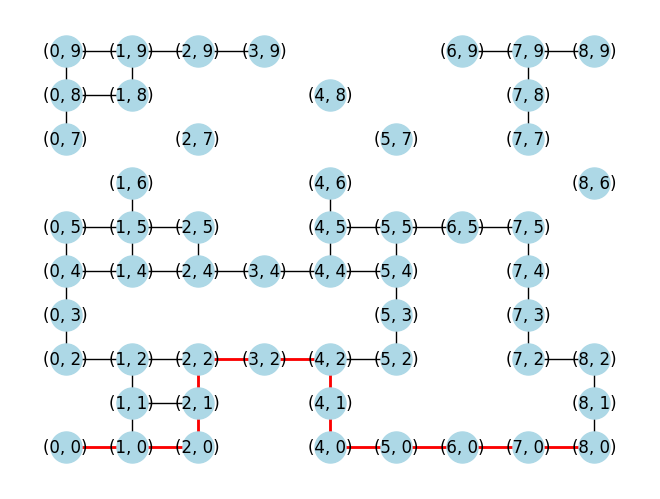

In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define the size of the grid
ROW = 9
COL = 10

# Define the grid (1 for unblocked, 0 for blocked)
grid = [
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 1, 1, 0, 1, 1, 0, 1, 0, 1],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 0, 1, 0, 0],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 1]
]

# Create a graph from the grid
def create_graph(grid):
    G = nx.Graph()
    for i in range(ROW):
        for j in range(COL):
            if grid[i][j] == 1:  # Only add unblocked nodes
                G.add_node((i, j))
                # Add edges to adjacent cells
                for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    if 0 <= i + di < ROW and 0 <= j + dj < COL and grid[i + di][j + dj] == 1:
                        G.add_edge((i, j), (i + di, j + dj), weight=1)
    return G

# Function to find shortest path
def find_shortest_path(grid, src, dest):
    G = create_graph(grid)
    try:
        path = nx.shortest_path(G, source=tuple(src), target=tuple(dest), weight='weight')
        return path
    except nx.NetworkXNoPath:
        print("No path found.")
        return None

# Main function
def main():
    src = [8, 0]
    dest = [0, 0]

    path = find_shortest_path(grid, src, dest)
    if path:
        print("The Path is:")
        print(" -> ".join(map(str, path)))

        # Optional: Visualize the grid and the path
        G = create_graph(grid)
        pos = {node: node for node in G.nodes()}
        nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue')
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
        plt.show()

if __name__ == "__main__":
    main()


# Referensi
- https://www.geeksforgeeks.org/a-search-algorithm/
- https://www.geeksforgeeks.org/level-order-tree-traversal/
- https://www.geeksforgeeks.org/depth-first-search-or-dfs-for-a-graph/
- https://medium.com/@defytamara2610/bfs-breadth-first-search-pengertian-kekurangan-kelebihan-dan-contohnya-775a7d808fbc
- https://rinagustiana.medium.com/implementasi-depth-first-search-dfs-dan-breadth-first-search-bfs-pada-python-62afe680925d
- https://networkx.org/documentation/stable/reference/algorithms/index.html